In [2]:
!pip install torch torchvision pandas tqdm scikit-learn matplotlib seaborn torchmetrics


  Using cached torchmetrics-1.8.2-py3-none-any.whl.metadata (22 kB)
  Using cached lightning_utilities-0.15.2-py3-none-any.whl.metadata (5.7 kB)
Using cached torchmetrics-1.8.2-py3-none-any.whl (983 kB)
Using cached lightning_utilities-0.15.2-py3-none-any.whl (29 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchmetrics] [torchmetrics]


In [1]:
import torch, torchvision
print("torch:", torch.__version__, torch.__file__)
print("torchvision:", torchvision.__version__, torchvision.__file__)


torch: 2.10.0+cu128 /home/na1488tr-s/Bachelor_Project_Statistics/.venv/lib/python3.10/site-packages/torch/__init__.py
torchvision: 0.25.0+cu128 /home/na1488tr-s/Bachelor_Project_Statistics/.venv/lib/python3.10/site-packages/torchvision/__init__.py


In [2]:
from PIL import Image

img = Image.open("Data/Size-data/Sorted_224_sizeTrain/Cichorium intybus//Cichorium intybus 1000318_79.png")
print(img.mode)   # RGB, L, RGBA, etc.
print(img.size)   # (width, height)

RGB
(224, 224)


In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy
from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset

from models.basemodel import CNNWithSizeMLP

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix
from engine.data_setup import setup_datasets

print("All libraries imported successfully!")

All libraries imported successfully!


## Preparing data

In [3]:
train_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain'
test_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest'
test_excel_path = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Size_features/size_data.xlsx'


def collect_filenames(root_dir):
    """
    Collect all image filenames recursively from root_dir.
    Returns list of filenames (without path).
    """
    filenames = []
    for species in os.listdir(root_dir):
        species_dir = os.path.join(root_dir, species)
        if not os.path.isdir(species_dir):
            continue

        for fn in os.listdir(species_dir):
            if fn.lower().endswith(('.png', '.jpg', '.jpeg')):
                filenames.append(fn)
    return filenames


# Collect filenames
train_files = collect_filenames(train_dir)
test_files  = collect_filenames(test_dir)

print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")

Train images: 8078
Test images: 1922


In [4]:
# Convert to pandas DataFrame
train_df = pd.DataFrame({'filename': train_files})
test_df  = pd.DataFrame({'filename': test_files})

# Extract flower ID (before underscore)
train_df['flower_id'] = train_df['filename'].str.split(' ').str[-1].str.split('_').str[0]
test_df['flower_id']  = test_df['filename'].str.split(' ').str[-1].str.split('_').str[0]

print(train_df.head())

                             filename flower_id
0  Tussilago farfara 1000328_3192.png   1000328
1  Tussilago farfara 1005387_1866.png   1005387
2  Tussilago farfara 1001625_1653.png   1001625
3  Tussilago farfara 1000328_1189.png   1000328
4   Tussilago farfara 1004811_656.png   1004811


In [5]:
train_flower_ids = set(train_df['flower_id'])
test_flower_ids  = set(test_df['flower_id'])

overlap = train_flower_ids.intersection(test_flower_ids)

print(f"Unique flower IDs in train: {len(train_flower_ids)}")
print(f"Unique flower IDs in test: {len(test_flower_ids)}")
print(f"Overlap in flower IDs: {len(overlap)}")

print(f"\n Overlapping flower IDs: {overlap}")


Unique flower IDs in train: 49
Unique flower IDs in test: 11
Overlap in flower IDs: 0

 Overlapping flower IDs: set()


In [6]:
def extract_species_from_filename(fn):
    # remove trailing "1234567_89.png"
    return " ".join(fn.split(" ")[:-1])

train_df["species"] = train_df["filename"].apply(extract_species_from_filename)
test_df["species"] = test_df["filename"].apply(extract_species_from_filename)

print(train_df.head())

                             filename flower_id            species
0  Tussilago farfara 1000328_3192.png   1000328  Tussilago farfara
1  Tussilago farfara 1005387_1866.png   1005387  Tussilago farfara
2  Tussilago farfara 1001625_1653.png   1001625  Tussilago farfara
3  Tussilago farfara 1000328_1189.png   1000328  Tussilago farfara
4   Tussilago farfara 1004811_656.png   1004811  Tussilago farfara


In [7]:
flowers_per_species = (
    train_df.groupby("species")["flower_id"]
    .nunique()
    .sort_values(ascending=False)
)
print("\nNumber of unique flowers per species in training set:")
print(flowers_per_species)


Number of unique flowers per species in training set:
species
Brassica napus             8
Cichorium intybus          8
Bellis perennis            6
Capsella bursa-pastoris    5
Tussilago farfara          5
Crepis capillaris          4
Hieracium umbellatum       4
Hypochaeris radicata       4
Tragopogon pratensis       3
Sonchus arvensis           2
Name: flower_id, dtype: int64


In [8]:
flowers_per_species = (
    test_df.groupby("species")["flower_id"]
    .nunique()
    .sort_values(ascending=False)
)
print("\nNumber of unique flowers per species in test set:")
print(flowers_per_species)


Number of unique flowers per species in test set:
species
Brassica napus             2
Bellis perennis            1
Capsella bursa-pastoris    1
Cichorium intybus          1
Crepis capillaris          1
Hieracium umbellatum       1
Hypochaeris radicata       1
Sonchus arvensis           1
Tragopogon pratensis       1
Tussilago farfara          1
Name: flower_id, dtype: int64


In [9]:
size_df = pd.read_excel(test_excel_path)

size_df["flower_id"] = (
    size_df["ping_name"]
    .astype(str)
    .str.split(" ").str[-1]
    .str.split("_").str[0]
)

size_df["species"] = size_df["anyname"]

print(size_df[["ping_name", "species", "flower_id", "majoraxis", "minoraxis"]].head())

                          ping_name          species flower_id  majoraxis  \
0  Bellis perennis 1001572_1013.png  Bellis perennis   1001572    26.1271   
1  Bellis perennis 1001572_1019.png  Bellis perennis   1001572    23.2606   
2  Bellis perennis 1001572_1022.png  Bellis perennis   1001572    25.6662   
3  Bellis perennis 1001572_1039.png  Bellis perennis   1001572    25.2603   
4  Bellis perennis 1001572_1057.png  Bellis perennis   1001572    28.9809   

   minoraxis  
0    24.5456  
1    22.8500  
2    24.1594  
3    24.8495  
4    25.3248  


In [10]:
train_size_df = size_df[size_df["ping_name"].isin(train_files)].copy()

print("Rows in Excel matching train images:", len(train_size_df))

Rows in Excel matching train images: 7922


In [11]:
test_size_df = size_df[size_df["ping_name"].isin(test_files)].copy()

print("Rows in Excel matching test images:", len(test_size_df))

Rows in Excel matching test images: 1922


In [12]:
flowers_with_size = (
    train_size_df.groupby("species")["flower_id"]
    .nunique()
    .sort_values(ascending=False)
)

print(flowers_with_size)

species
Brassica napus             8
Cichorium intybus          8
Bellis perennis            6
Capsella bursa-pastoris    5
Tussilago farfara          5
Crepis capillaris          4
Hieracium umbellatum       4
Hypochaeris radicata       4
Tragopogon pratensis       3
Sonchus arvensis           2
Name: flower_id, dtype: int64


In [13]:
flower_stats = (
    train_size_df.groupby(["species", "flower_id"])[["majoraxis", "minoraxis"]]
    .agg(["mean", "min", "max", "std", "count"])
)

print(flower_stats.head(20))

                                   majoraxis                              \
                                        mean      min      max       std   
species                 flower_id                                          
Bellis perennis         1001572    26.320650  23.2385  33.0703  1.716378   
                        1001608    27.114877  24.0684  34.1115  1.516820   
                        1005368    25.034638  21.8982  28.0013  1.257750   
                        1005371    25.595876  21.9446  29.1698  1.092296   
                        1005375    25.943041  23.8515  28.5592  0.830309   
                        1010522    32.143966  25.6433  55.9076  5.019230   
Brassica napus          1000406    32.008393  25.9912  88.1456  6.310122   
                        1001635    32.018241  29.1124  36.0160  1.153289   
                        1001647    31.440242  28.4073  35.1298  1.421175   
                        1004452    29.955979  26.6673  34.8066  1.634507   
            

In [14]:
flower_stats_test = (
    test_size_df.groupby(["species", "flower_id"])[["majoraxis", "minoraxis"]]
    .agg(["mean", "min", "max", "std", "count"])
)

print(flower_stats_test.head(20))

                                   majoraxis                                  \
                                        mean        min        max       std   
species                 flower_id                                              
Bellis perennis         1011316    31.000509  24.694300  69.086500  6.439596   
Brassica napus          1005374    30.327466  27.481500  34.499400  1.424094   
                        1005376    31.582086  28.571600  35.733100  1.448889   
Capsella bursa-pastoris 1005390    21.056386  19.629900  23.424500  0.685738   
Cichorium intybus       1005458    55.447239  49.422400  70.668400  3.516886   
Crepis capillaris       1010538    31.408135  24.413900  44.150300  2.955771   
Hieracium umbellatum    1012176    39.923724  28.081200  54.015800  3.795854   
Hypochaeris radicata    1012069    36.651733  25.864700  47.320500  3.489914   
Sonchus arvensis        1011968    50.685328  33.653500  63.155300  4.486087   
Tragopogon pratensis    1017595    48.62

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_all_species_flower_sizes(df, species_order=None, figsize=(22, 10)
    ,title_fontsize =18
    ,label_fontsize=15
    ,tick_fontsize=13):
    """
    Plot majoraxis vs minoraxis for all species, colored by flower_id.
    One subplot per species.
    """

    if species_order is None:
        species_order = sorted(df["species"].dropna().unique())

    n_species = len(species_order)
    ncols = 3
    nrows = math.ceil(n_species / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, species_name in enumerate(species_order):
        ax = axes[i]
        sub = df[df["species"] == species_name].copy()

        sns.scatterplot(
            data=sub,
            x="majoraxis",
            y="minoraxis",
            hue="flower_id",
            alpha=0.7,
            ax=ax,
            legend=False   # important, otherwise too crowded
        )

        ax.set_title(species_name, fontsize=10)
        ax.set_xlabel("Major axis")
        ax.set_ylabel("Minor axis")

    # hide unused panels if any
    for j in range(n_species, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig("train_species_flower_sizes.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.show()

In [128]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import math
import numpy as np

def plot_all_species_flower_sizes(
    df,
    species_order=None,
    ncols=3,
    panel_width=4.2,
    panel_height=4.2,
    title_fontsize=22,
    label_fontsize=20,
    tick_fontsize=17,
    save_path="train_species_flower_sizes.pdf",
    dpi=300,
    pad_frac=0.0005
):
    """
    Plot majoraxis vs minoraxis for all species, colored by flower_id.
    One subplot per species.
    All subplots use the same x/y scale.
    Figure size is chosen to avoid unnecessary whitespace.
    """

    if species_order is None:
        species_order = sorted(df["species"].dropna().unique())

    n_species = len(species_order)
    nrows = math.ceil(n_species / ncols)

    # Global limits across all data
    x_min = df["majoraxis"].min()
    x_max = df["majoraxis"].max()
    y_min = df["minoraxis"].min()
    y_max = df["minoraxis"].max()

    x_pad = (x_max - x_min) * pad_frac
    y_pad = (y_max - y_min) * pad_frac

    x_lim = (x_min - x_pad, x_max + x_pad)
    y_lim = (y_min - y_pad, y_max + y_pad)

    # Better overall figure size
    figsize = (ncols * panel_width, nrows * panel_height)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True
    )
    fig.set_constrained_layout_pads(
    h_pad=0.1,  
    #w_pad=0.02,   # horizontal space between columns
    #hspace=0.15,  # extra row spacing multiplier
    #wspace=0.05   # extra column spacing multiplier
    )

    axes = np.atleast_1d(axes).flatten()

    for i, species_name in enumerate(species_order):
        ax = axes[i]
        sub = df[df["species"] == species_name].copy()

        sns.scatterplot(
            data=sub,
            x="majoraxis",
            y="minoraxis",
            hue="flower_id",
            alpha=0.7,
            ax=ax,
            legend=False,
            s=28
        )

        ax.set_title(f"{species_name}", fontsize=title_fontsize, pad=10)
        ax.set_xlabel("Major axis", fontsize=label_fontsize)
        ax.set_ylabel("Minor axis", fontsize=label_fontsize)
        ax.tick_params(axis="both", labelsize=tick_fontsize)

        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_aspect("equal", adjustable="box")

        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
        #remove box, keep axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)
        
        # Major ticks (with labels)
        ax.yaxis.set_major_locator(MultipleLocator(10))   # e.g. every 5%

        # Minor ticks (no labels)
        ax.yaxis.set_minor_locator(MultipleLocator(5))   # every 1%
        
        # Major ticks (with labels)
        ax.xaxis.set_major_locator(MultipleLocator(10))   # e.g. every 5%

        # Minor ticks (no labels)
        ax.xaxis.set_minor_locator(MultipleLocator(5))   # every 1%

    # Force x-axis label and tick labels on the used bottom-row panels
    bottom_row_start = (nrows - 1) * ncols
    bottom_used_end = n_species

    for j in range(bottom_row_start, bottom_used_end):
        ax = axes[j]
        ax.set_xlabel("Major axis", fontsize=label_fontsize)
        ax.tick_params(axis="x", labelbottom=True)

    for j in range(n_species, len(axes)):
        fig.delaxes(axes[j])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

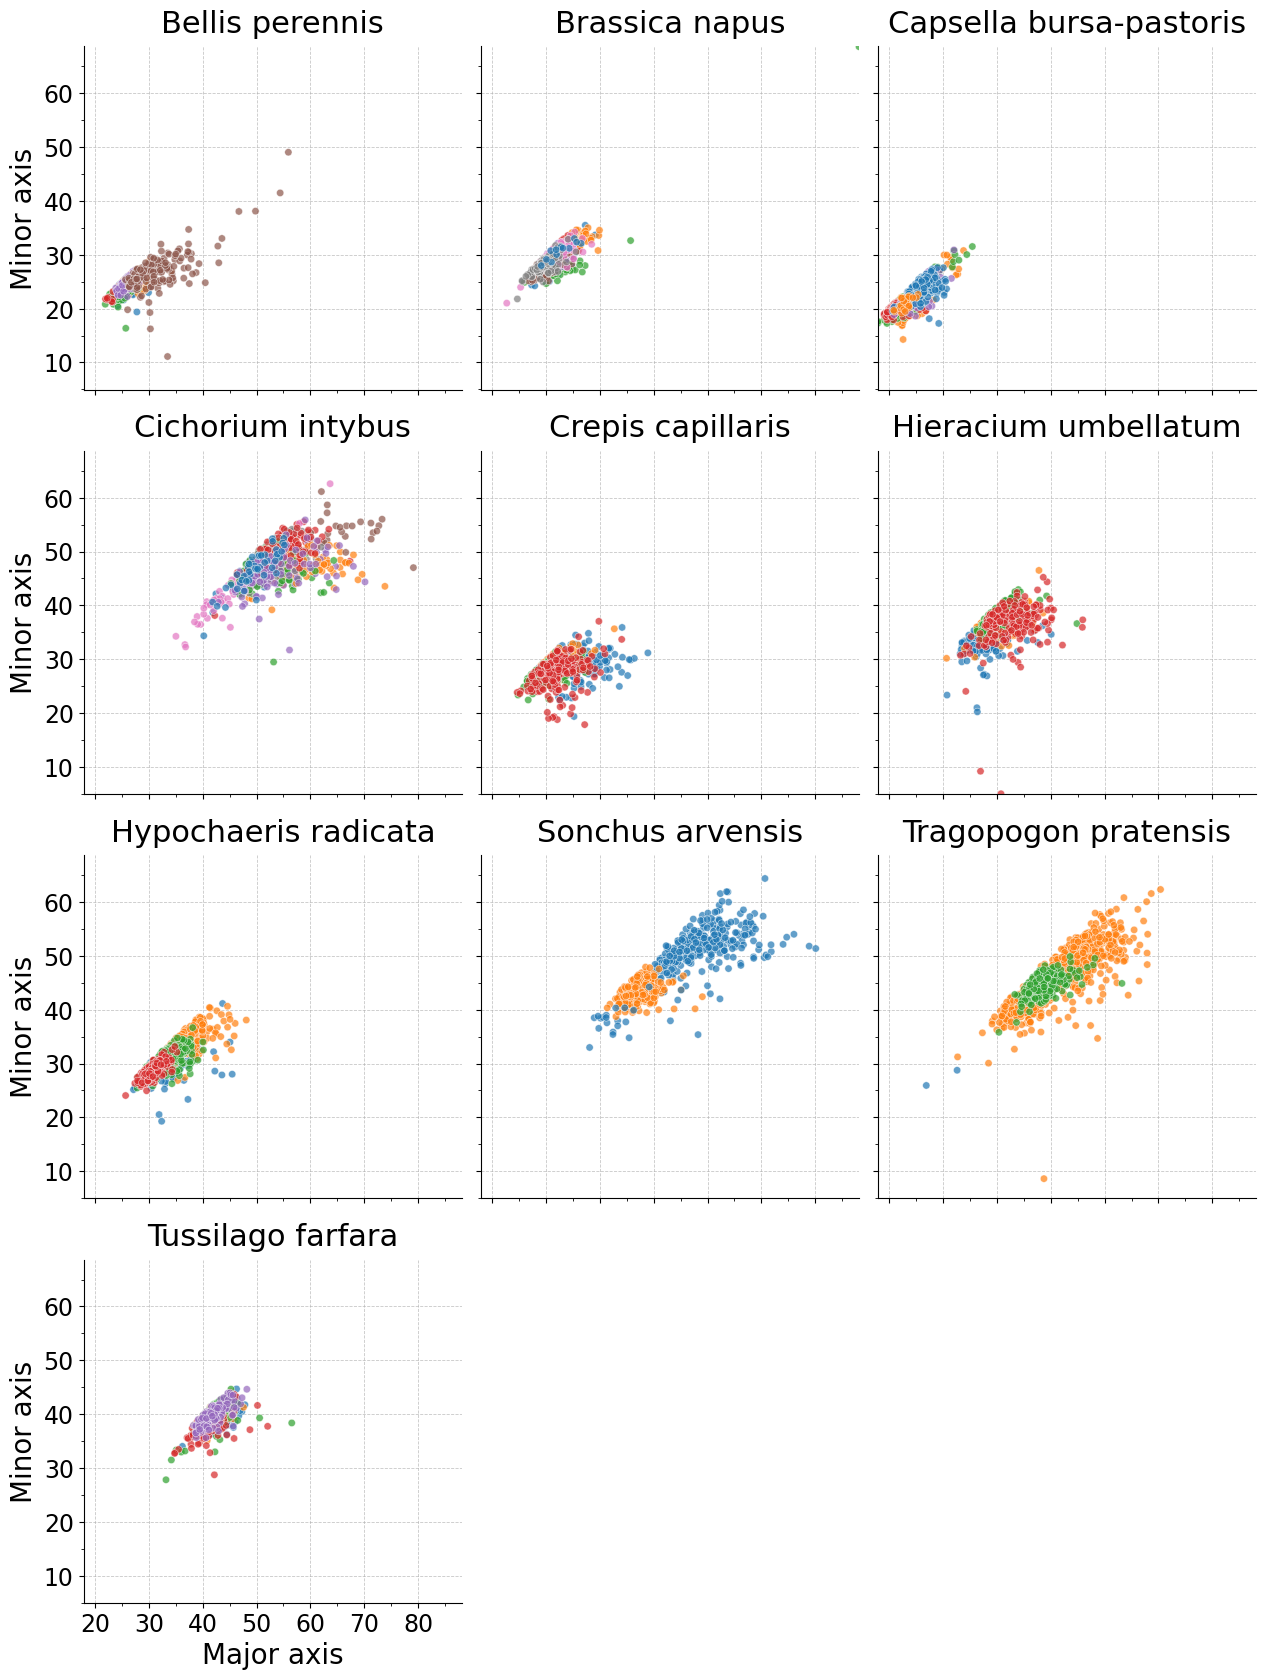

In [129]:
species_order = [
    "Bellis perennis",
    "Brassica napus",
    "Capsella bursa-pastoris",
    "Cichorium intybus",
    "Crepis capillaris",
    "Hieracium umbellatum",
    "Hypochaeris radicata",
    "Sonchus arvensis",
    "Tragopogon pratensis",
    "Tussilago farfara"
]

plot_all_species_flower_sizes(train_size_df, species_order=species_order, save_path="train_species_flower_sizes.pdf")

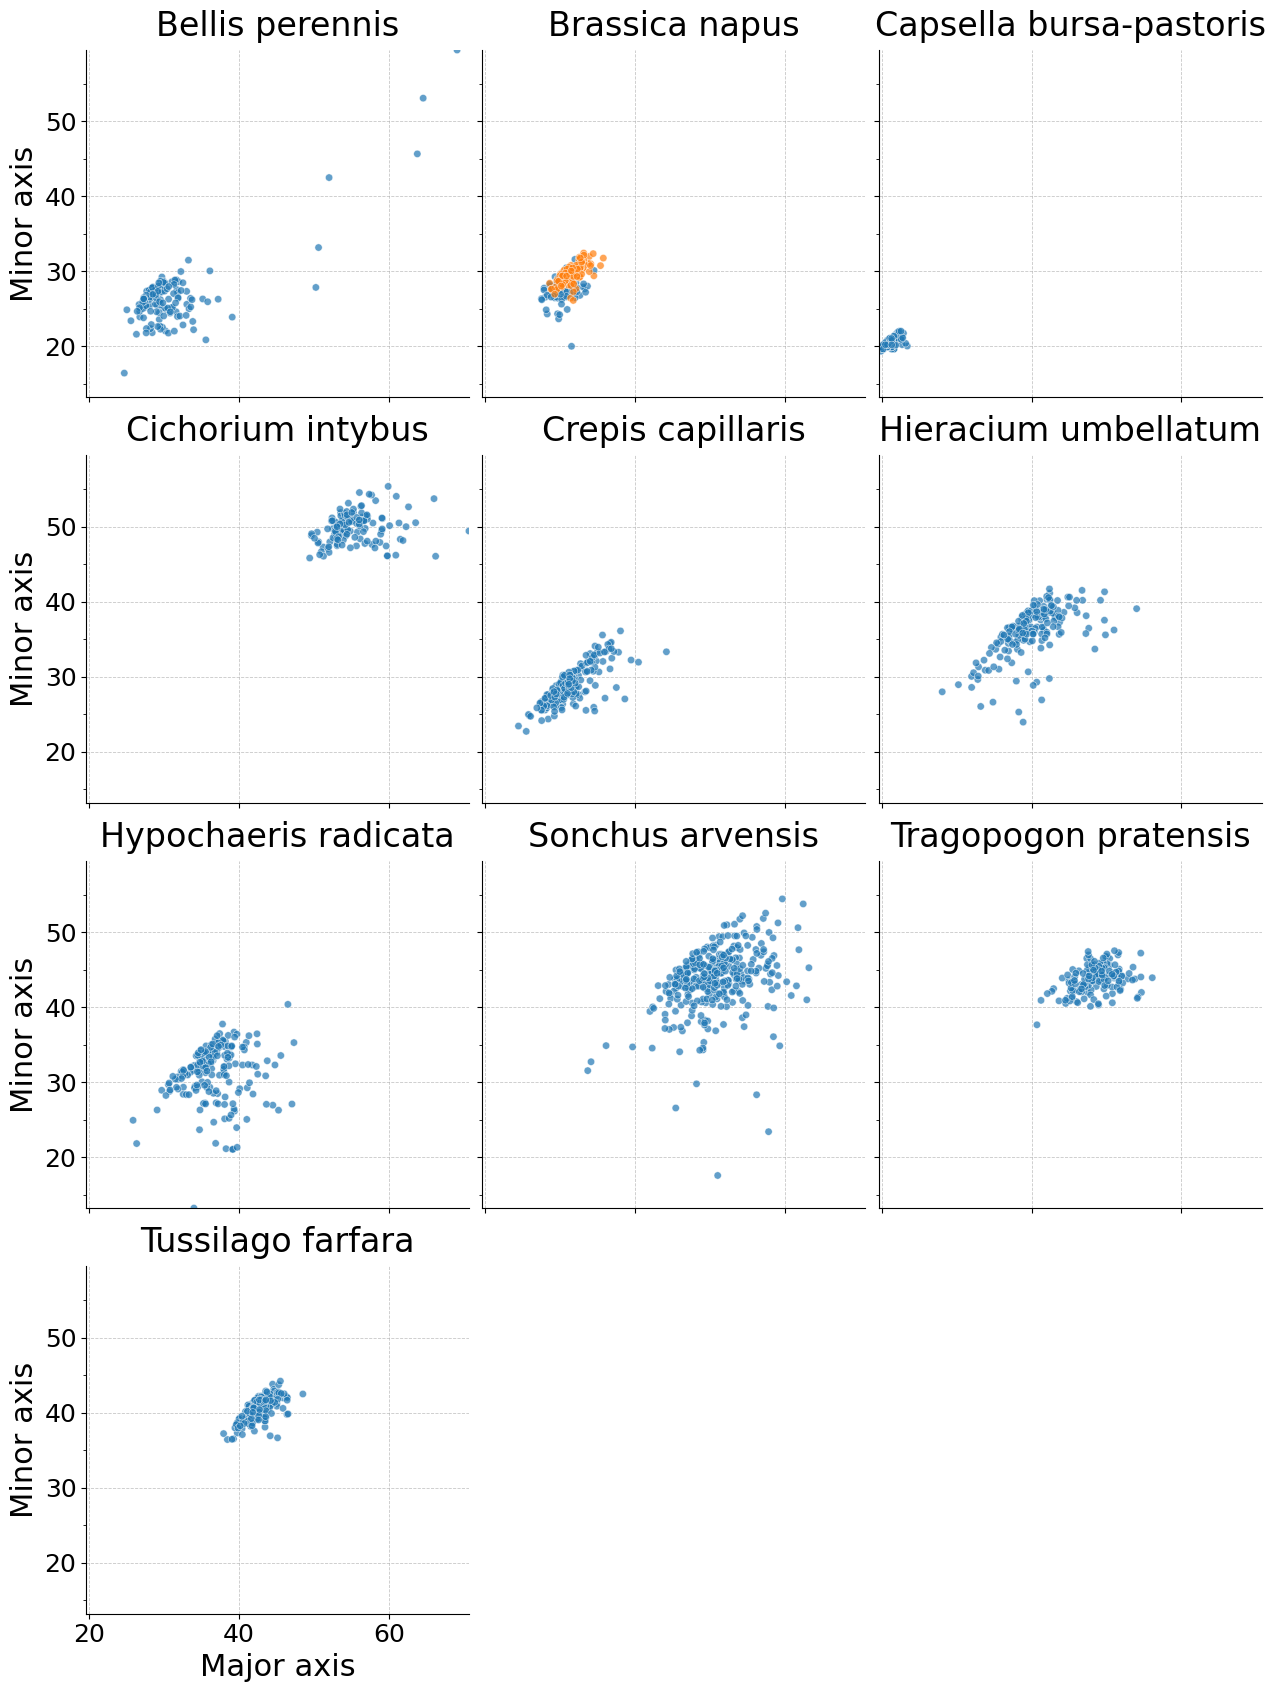

In [42]:
species_order = [
    "Bellis perennis",
    "Brassica napus",
    "Capsella bursa-pastoris",
    "Cichorium intybus",
    "Crepis capillaris",
    "Hieracium umbellatum",
    "Hypochaeris radicata",
    "Sonchus arvensis",
    "Tragopogon pratensis",
    "Tussilago farfara"
]

plot_all_species_flower_sizes(test_size_df, species_order=species_order)

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

def plot_train_test_species_sizes(train_df, test_df, species_order=None, figsize=(22, 10)):
    """
    Plot majoraxis vs minoraxis for all species.
    One subplot per species.
    Train and test are shown in two different colors.
    """

    # Add a column to identify dataset
    train_plot = train_df.copy()
    test_plot = test_df.copy()

    train_plot["dataset"] = "Train"
    test_plot["dataset"] = "Test"

    # Combine both
    df = pd.concat([train_plot, test_plot], ignore_index=True)

    if species_order is None:
        species_order = sorted(df["species"].dropna().unique())

    n_species = len(species_order)
    ncols = 5
    nrows = math.ceil(n_species / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, species_name in enumerate(species_order):
        ax = axes[i]
        sub = df[df["species"] == species_name].copy()

        sns.scatterplot(
            data=sub,
            x="majoraxis",
            y="minoraxis",
            hue="dataset",
            alpha=0.7,
            ax=ax
        )

        ax.set_title(species_name, fontsize=10)
        ax.set_xlabel("Major axis")
        ax.set_ylabel("Minor axis")
        ax.legend(title=None)
    # hide unused panels if any
    for j in range(n_species, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.savefig("train_test_species_sizes.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.show()

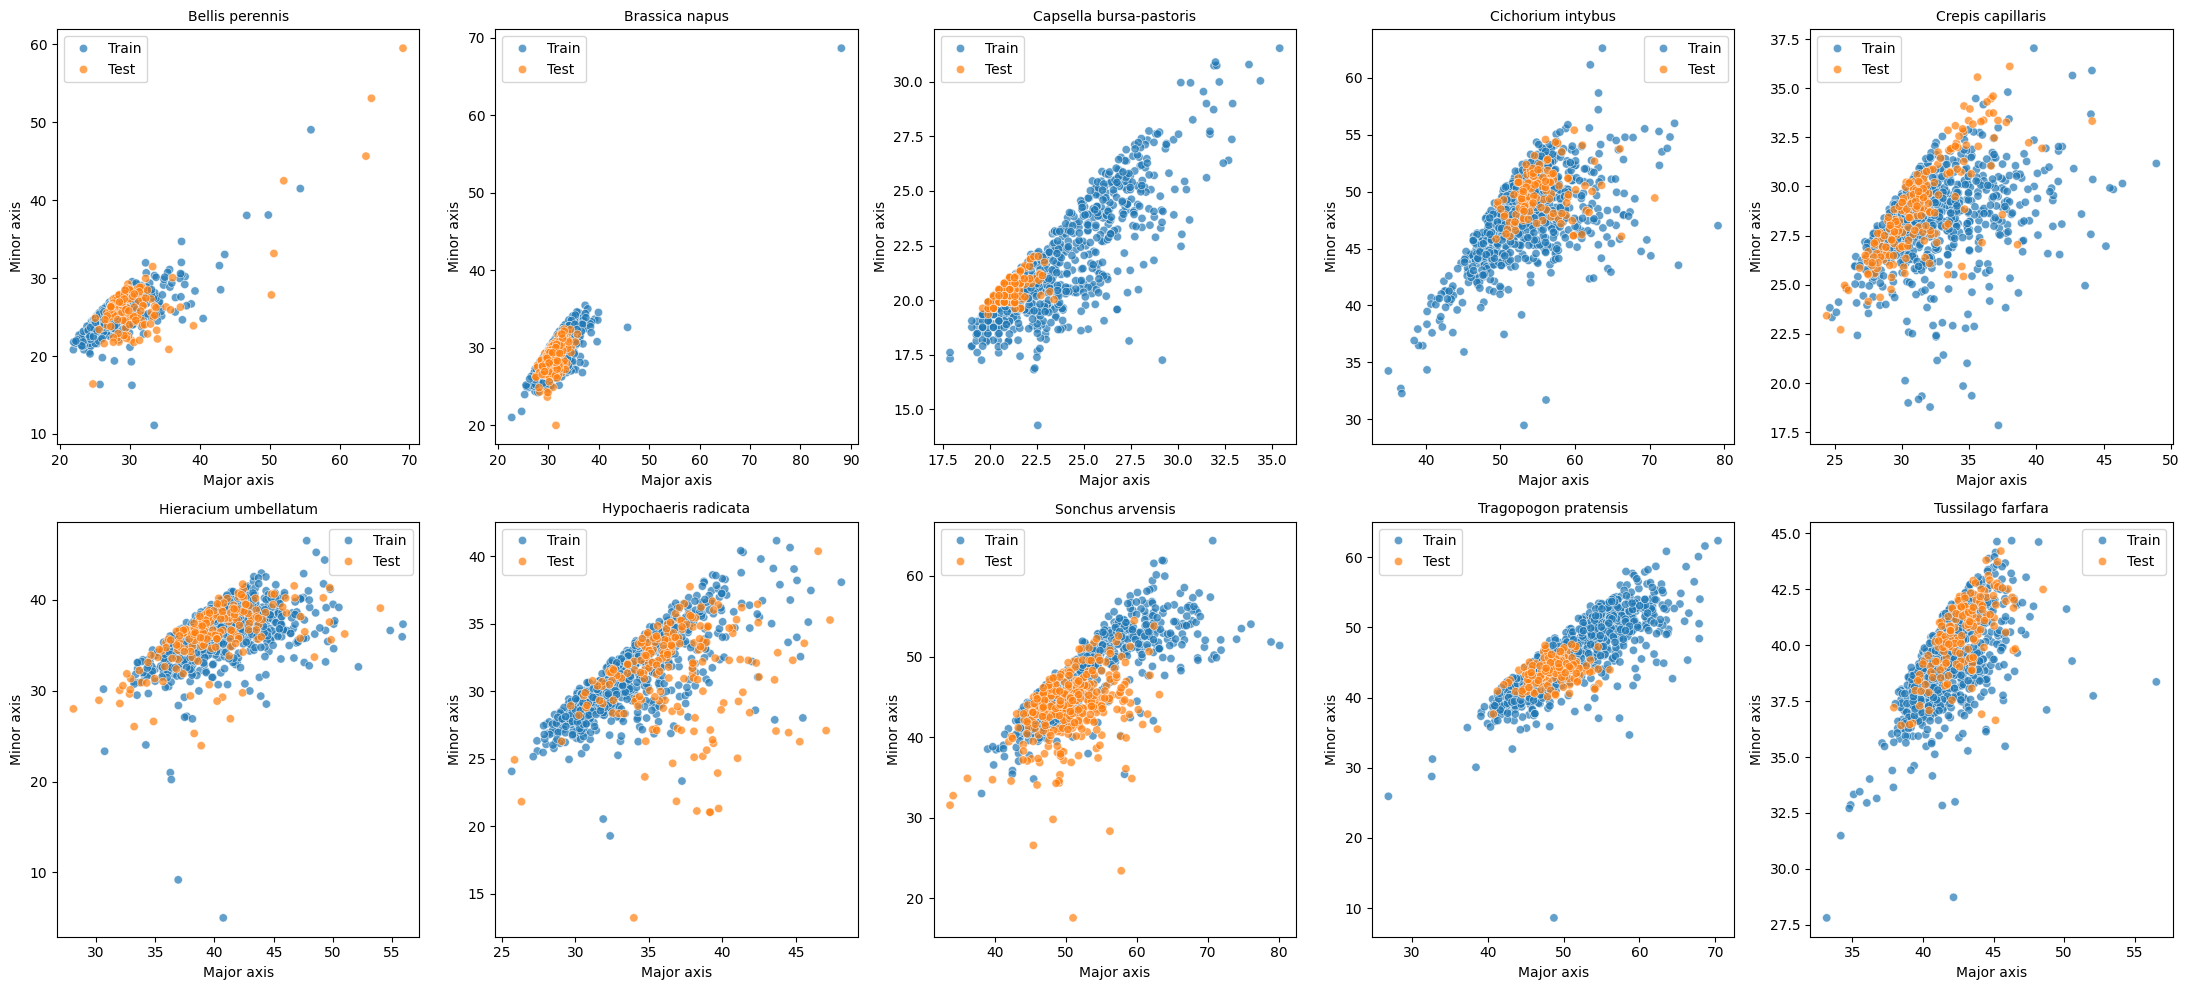

In [44]:
plot_train_test_species_sizes(train_size_df, test_size_df)

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import numpy as np

def plot_train_test_species_sizes(
    train_df,
    test_df,
    species_order=None,
    ncols=3,
    panel_width=4.2,
    panel_height=4.2,
    title_fontsize=22,
    label_fontsize=20,
    tick_fontsize=17,
    legend_fontsize=18,
    point_size=28,
    alpha=0.7,
    pad_frac=0.0005,
    save_path="train_test_species_sizes.pdf",
    dpi=300
):

    """
    Plot majoraxis vs minoraxis for all species.
    One subplot per species.
    Train and test are shown in two different colors.
    All subplots use the same scale, same ticks, and same grid.
    """

    # Add dataset label
    train_plot = train_df.copy()
    test_plot = test_df.copy()
    train_plot["dataset"] = "Train"
    test_plot["dataset"] = "Test"

    # Combine
    df = pd.concat([train_plot, test_plot], ignore_index=True)


    

    if species_order is None:
        species_order = sorted(df["species"].dropna().unique())

    n_species = len(species_order)
    nrows = math.ceil(n_species / ncols)

    # Global limits across all data
    x_min = df["majoraxis"].min()
    x_max = df["majoraxis"].max()
    y_min = df["minoraxis"].min()
    y_max = df["minoraxis"].max()

    x_pad = (x_max - x_min) * pad_frac
    y_pad = (y_max - y_min) * pad_frac

    x_lim = (x_min - x_pad, x_max + x_pad)
    y_lim = (y_min - y_pad, y_max + y_pad)

    # Same ticks for every subplot
    x_ticks = np.linspace(round(x_lim[0]), round(x_lim[1]), 5)
    y_ticks = np.linspace(round(y_lim[0]), round(y_lim[1]), 5)

    figsize = (ncols * panel_width, nrows * panel_height)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True
    )
    fig.set_constrained_layout_pads(
    h_pad=0.1,  
    #w_pad=0.02,   # horizontal space between columns
    #hspace=0.15,  # extra row spacing multiplier
    #wspace=0.05   # extra column spacing multiplier
    )
    axes = np.atleast_1d(axes).flatten()

    palette = {"Train": "tab:blue", "Test": "tab:orange"}

    for i, species_name in enumerate(species_order):
        ax = axes[i]
        sub = df[df["species"] == species_name].copy()

        sns.scatterplot(
            data=sub,
            x="majoraxis",
            y="minoraxis",
            hue="dataset",
            hue_order=["Train", "Test"],
            palette=palette,
            alpha=alpha,
            s=point_size,
            ax=ax,
            legend=False
        )

        ax.set_title(f"{species_name}", fontsize=title_fontsize, pad=8)
       
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_xticks(x_ticks)
        ax.set_yticks(y_ticks)

        ax.tick_params(axis="both", which="both", labelsize=tick_fontsize)


        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(True)
        
        # Major ticks (with labels)
        ax.yaxis.set_major_locator(MultipleLocator(10))   # e.g. every 5%

        # Minor ticks (no labels)
        ax.yaxis.set_minor_locator(MultipleLocator(5))   # every 1%
        
        # Major ticks (with labels)
        ax.xaxis.set_major_locator(MultipleLocator(10))   # e.g. every 5%

        # Minor ticks (no labels)
        ax.xaxis.set_minor_locator(MultipleLocator(5))   # every 1%
    for i, ax in enumerate(axes[:n_species]):
        row = i // ncols
        col = i % ncols

        # X-axis: keep ticks everywhere, labels only bottom row
        if row == nrows - 1:
            ax.set_xlabel("Major axis", fontsize=label_fontsize)
            ax.tick_params(axis="x", which="both",
                        bottom=True, labelbottom=True)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", which="both",
                        bottom=True, labelbottom=False)  

        # Y-axis: keep ticks everywhere, labels only left column
        if col == 0:
            ax.set_ylabel("Minor axis", fontsize=label_fontsize)
            ax.tick_params(axis="y", which="both",
                        left=True, labelleft=True)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", which="both",
                        left=True, labelleft=False)     

    for j in range(n_species, len(axes)):
        fig.delaxes(axes[j])

    # One shared legend for whole figure
    handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=palette["Train"], markeredgecolor='black',
                   markersize=7, label="Train"),
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=palette["Test"], markeredgecolor='black',
                   markersize=7, label="Test")
    ]

    fig.legend(
        handles=handles,
        labels=["Train", "Test"],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=2,
        fontsize=legend_fontsize,
        frameon=True,
        
    )
 
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

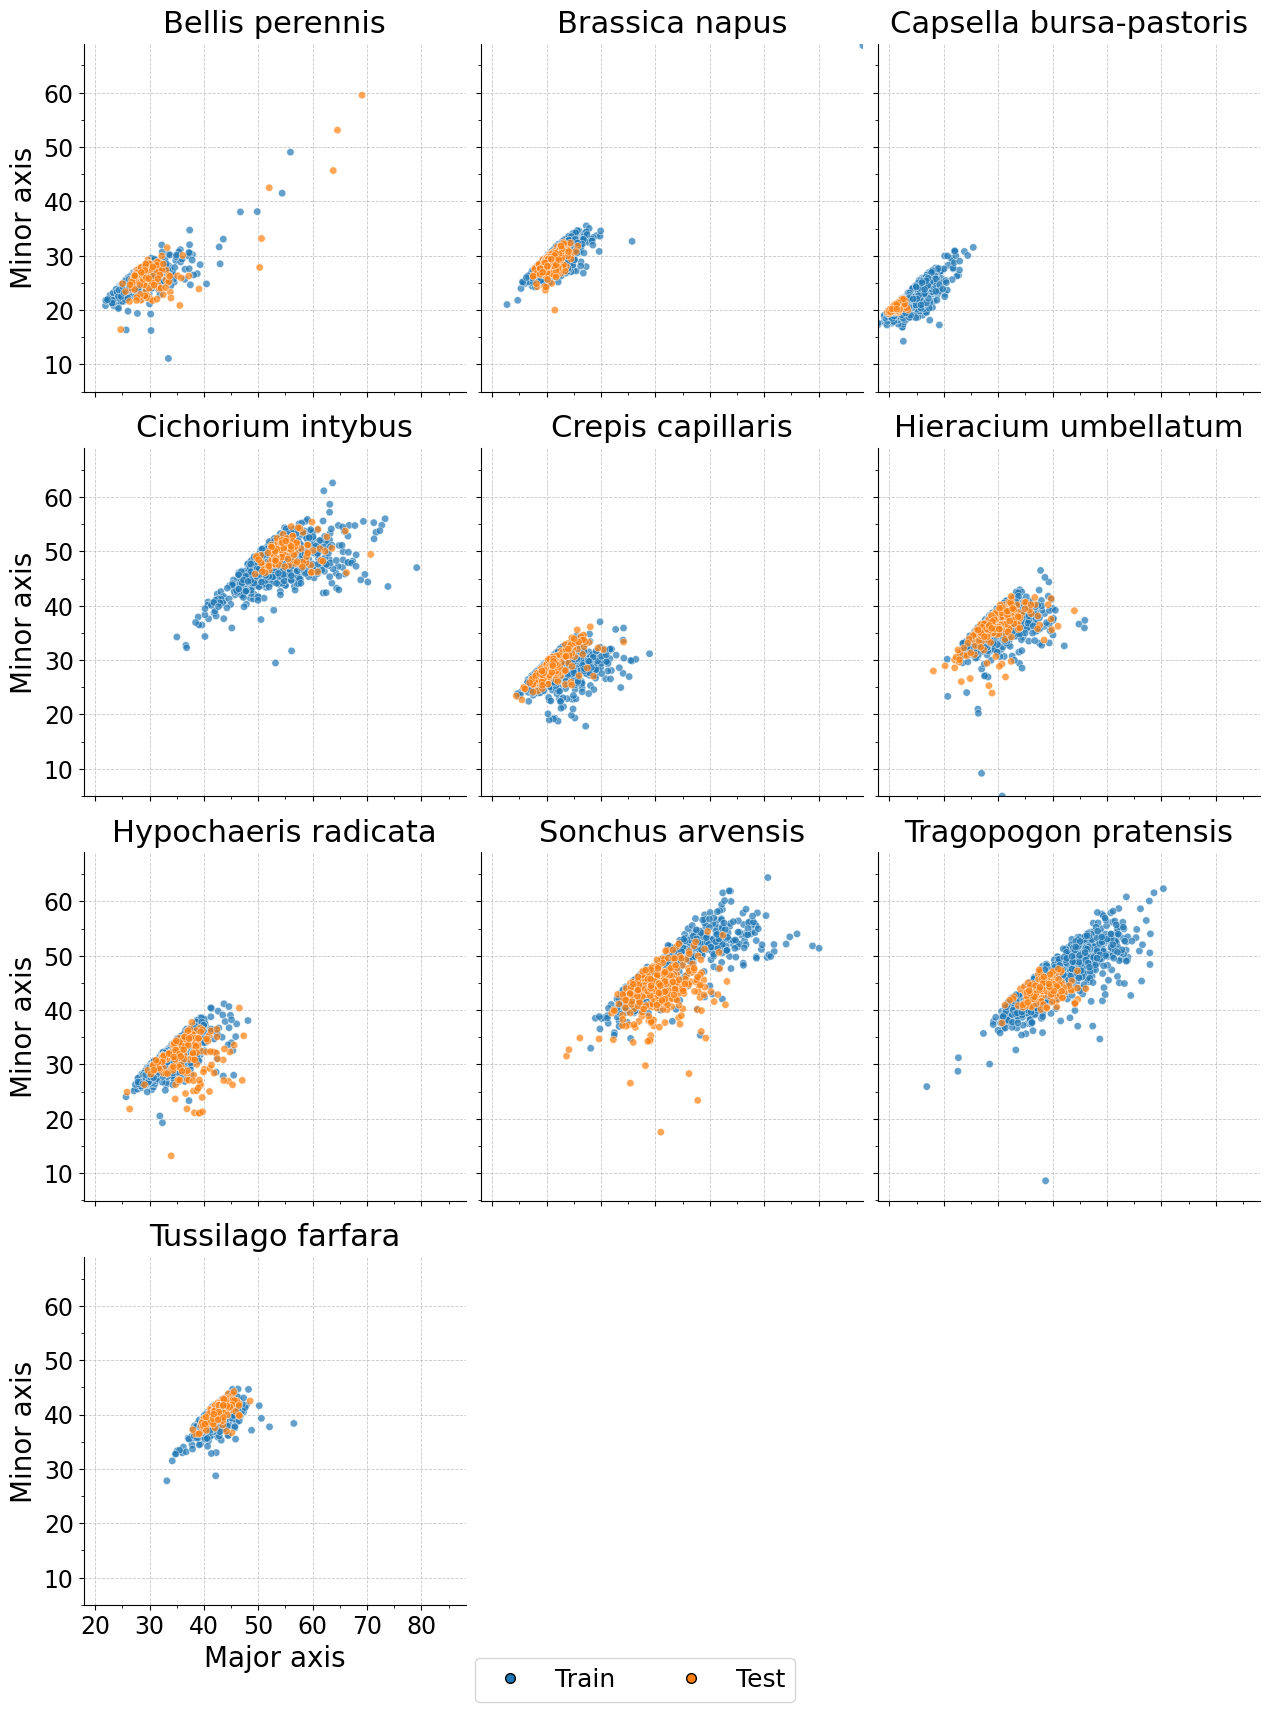

In [131]:
plot_train_test_species_sizes(train_size_df, test_size_df)

In [134]:
import os
import pandas as pd

train_dir = "/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain"
size_excel_path = "/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Size_features/size_data.xlsx"


def make_image_key(filename):
    base = os.path.basename(str(filename))
    stem = os.path.splitext(base)[0]
    return stem.strip().lower()


def extract_flower_id_from_filename(filename):
    base = os.path.basename(str(filename))
    stem = os.path.splitext(base)[0]
    return stem.split(" ")[-1].split("_")[0]


def collect_image_records(root_dir):
    records = []

    for species in sorted(os.listdir(root_dir)):
        species_dir = os.path.join(root_dir, species)

        if not os.path.isdir(species_dir):
            continue

        for fn in sorted(os.listdir(species_dir)):
            if fn.lower().endswith((".png", ".jpg", ".jpeg")):
                records.append({
                    "Species": species,
                    "Flower ID": extract_flower_id_from_filename(fn),
                    "_image_key": make_image_key(fn)
                })

    return pd.DataFrame(records)


# 1. Collect train images
train_images = collect_image_records(train_dir)

print(f"Train images found: {len(train_images)}")


# 2. Read size metadata
size_df = pd.read_excel(size_excel_path)

size_df["_image_key"] = size_df["ping_name"].apply(make_image_key)

size_lookup = (
    size_df[["_image_key", "majoraxis", "minoraxis"]]
    .drop_duplicates("_image_key")
)


# 3. Merge train images with size metadata
train_merged = train_images.merge(
    size_lookup,
    on="_image_key",
    how="left"
)

train_merged["missing_size_flag"] = (
    train_merged["majoraxis"].isna() | train_merged["minoraxis"].isna()
).astype(int)

print(
    "Images with missing or unmatched size values:",
    train_merged["missing_size_flag"].sum()
)


# 4. Summarize by Species and Flower ID
train_flower_summary = (
    train_merged
    .groupby(["Species", "Flower ID"], as_index=False)
    .agg(
        Images=("Flower ID", "size"),
        **{"Missing size count": ("missing_size_flag", "sum")}
    )
    .sort_values(["Species", "Flower ID"])
    .reset_index(drop=True)
)

print(train_flower_summary)


# 5. Save final clean table
output_path = "train_flower_summary_missing_sizes.csv"
train_flower_summary.to_csv(output_path, index=False)

print(f"Saved summary to: {output_path}")

Train images found: 8078
Images with missing or unmatched size values: 156
                    Species Flower ID  Images  Missing size count
0           Bellis perennis   1001572     143                   0
1           Bellis perennis   1001608     143                   2
2           Bellis perennis   1005368     143                   0
3           Bellis perennis   1005371     143                   0
4           Bellis perennis   1005375     143                   0
5           Bellis perennis   1010522     143                   0
6            Brassica napus   1000406     100                   4
7            Brassica napus   1001635     100                   1
8            Brassica napus   1001647     100                   0
9            Brassica napus   1004452     100                   0
10           Brassica napus   1004453     100                   0
11           Brassica napus   1004454     100                   0
12           Brassica napus   1004455     100                   0
1

## Reading excel

In [16]:
size_lookup, species_mean_lookup, global_mean, global_std = lookup_size_from_excel(test_excel_path)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
#train_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor
#test_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor

train_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = PollenFolderWithSizeDataset(img_dir=train_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=train_tf)
test_dataset = PollenFolderWithSizeDataset(img_dir=test_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=test_tf)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.


UnboundLocalError: local variable 'stats_df' referenced before assignment

In [3]:
from engine.data_setup import setup_datasets
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=False,
    aug_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 8078
Dataset setup complete.


In [6]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])


In [ ]:
train_counts = Counter(train_dataset.targets)

In [7]:
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 856
1 Brassica napus 795
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 799
5 Hieracium umbellatum 735
6 Hypochaeris radicata 717
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [ ]:

print("\nTest set class distribution:")
for k in sorted(test_counts):
    print(k, idx_to_class[int(k)], test_counts[k])


Test set class distribution:
0 Bellis perennis 142
1 Brassica napus 200
2 Capsella bursa-pastoris 183
3 Cichorium intybus 130
4 Crepis capillaris 200
5 Hieracium umbellatum 200
6 Hypochaeris radicata 200
7 Sonchus arvensis 334
8 Tragopogon pratensis 166
9 Tussilago farfara 167


In [4]:
def train_epoch(model, loader, device, optimizer, loss_fn):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for imgs, sizes, labels in tqdm(loader):
        imgs = imgs.to(device)
        sizes = sizes.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, sizes)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def eval_epoch(model, loader, device, recall_metric, accuracy_metric, loss_fn=None):
    model.eval()
    
    recall_metric.reset()
    accuracy_metric.reset()
    
    total_loss = 0
    batches = 0
    
    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            sizes = sizes.to(device)
            labels = labels.to(device)

            outputs = model(imgs, sizes)
            preds = outputs.argmax(dim=1)
            
            recall_metric.update(preds, labels)
            accuracy_metric.update(preds, labels)
            
            if loss_fn is not None:
                loss = loss_fn(outputs, labels)
                total_loss += loss.item()
                batches += 1
            
    recall_per_class = recall_metric.compute().cpu() # tensor of shape (num_classes,)
    accuracy = accuracy_metric.compute().cpu().item() # scalar
    val_loss = total_loss / batches if loss_fn is not None else None
    
    return recall_per_class, accuracy, val_loss

## Base Model (Erik's)

In [4]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [21]:
# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 20

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
#val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

history = {
    "train_loss": []
    ,"train_acc": []
    #,"val_loss": []
    #,"val_acc": []
}

best_train_acc = 0.0   # initialize before loop
print_every = 5

for epoch in range(1, EPOCHS_NUM + 1):
    train_loss, train_acc = train_epoch(model, train_loader, device, optimizer, loss_fn)
    #val_recall_per_class, val_acc, val_loss = eval_epoch(model, val_loader, device, recall_metric, accuracy_metric, loss_fn)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    #history["val_loss"].append(val_loss)
    #history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train loss {train_loss:.4f}, train accuracy {train_acc:.4f} | ")
    """
    print(f"val loss {val_loss:.4f}, val accuracy {val_acc:.4f}")
    if epoch == 1 or epoch % print_every == 0:
        print(f"Val Recall per class: {val_recall_per_class}")
    
    if train_acc > best_train_acc:
        best_train_acc = train_acc
        torch.save(model.state_dict(), "base_model.pth")
        print(f"Saved new best model with train accuracy {best_train_acc:.4f}! ") #And recall per class: {val_recall_per_class}.
    """
torch.save(model.state_dict(), "models/saved_models/base_model.pth")

100%|██████████| 248/248 [00:22<00:00, 10.98it/s]


Epoch 1: train loss 0.2709, train accuracy 0.9099 | 


100%|██████████| 248/248 [00:22<00:00, 11.16it/s]


Epoch 2: train loss 0.1146, train accuracy 0.9629 | 


100%|██████████| 248/248 [00:22<00:00, 11.12it/s]


...

Epoch 18: train loss 0.0306, train accuracy 0.9894 | 


100%|██████████| 248/248 [00:22<00:00, 11.02it/s]


Epoch 19: train loss 0.0361, train accuracy 0.9894 | 


100%|██████████| 248/248 [00:22<00:00, 10.98it/s]


Epoch 20: train loss 0.0132, train accuracy 0.9953 | 


In [9]:
# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 20

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
#val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
print("\nTraining complete.")
print("Loading best model for final test evaluation...")

model.load_state_dict(torch.load("models/saved_models/base_model.pth"))

test_recall_per_class, test_acc, _,_ = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, None,None,True)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Recall per class: {test_recall_per_class}")


Training complete.
Loading best model for final test evaluation...

=== Backbone Feature Inspection ===
Min of mins: 0.0
Max of maxs: 8.56888198852539
Mean of batch means: 0.8188163002983468
Mean of batch stds: 1.0040662923797232


Final Test Accuracy: 0.7555
Final Test Recall per class: tensor([0.2042, 1.0000, 0.8197, 1.0000, 0.0000, 0.9650, 0.8150, 0.7665, 0.9880,
        1.0000])


## Test to fill missing sizes


In [24]:

train_dataset = PollenFolderWithSizeDataset(img_dir=train_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, fill_missing_bool = True,transform=train_tf)
test_dataset = PollenFolderWithSizeDataset(img_dir=test_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=test_tf)


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.


In [25]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])


In [26]:
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 858
1 Brassica napus 800
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 800
5 Hieracium umbellatum 800
6 Hypochaeris radicata 800
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [35]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
fill_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fill_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [ ]:
# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 

from train_model import train_model

history, best_val_acc, test_loader = train_model(fill_model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name= "fill_model.pth")

SyntaxError: invalid syntax (2493288486.py, line 16)

In [ ]:
# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 10

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
#val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

history = {
    "train_loss": []
    ,"train_acc": []
    #,"val_loss": []
    #,"val_acc": []
}

best_train_acc = 0.0   # initialize before loop
print_every = 5

for epoch in range(1, EPOCHS_NUM + 1):
    train_loss, train_acc = train_epoch(fill_model, train_loader, device, optimizer, loss_fn)
    #val_recall_per_class, val_acc, val_loss = eval_epoch(model, val_loader, device, recall_metric, accuracy_metric, loss_fn)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    #history["val_loss"].append(val_loss)
    #history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train loss {train_loss:.4f}, train accuracy {train_acc:.4f} | ")
    """
    print(f"val loss {val_loss:.4f}, val accuracy {val_acc:.4f}")
    if epoch == 1 or epoch % print_every == 0:
        print(f"Val Recall per class: {val_recall_per_class}")
    
    if train_acc > best_train_acc:
        best_train_acc = train_acc
        torch.save(fill_model.state_dict(), "models/saved_models/fill_model.pth")
        print(f"Saved new best model with train accuracy {best_train_acc:.4f}! ") #And recall per class: {val_recall_per_class}.
    """    
torch.save(fill_model.state_dict(), "models/saved_models/fill_model.pth")

100%|██████████| 253/253 [00:22<00:00, 11.00it/s]


Epoch 1: train loss 0.0140, train accuracy 0.9959 | 


100%|██████████| 253/253 [00:22<00:00, 11.12it/s]


Epoch 2: train loss 0.0155, train accuracy 0.9947 | 


100%|██████████| 253/253 [00:22<00:00, 11.25it/s]


...

Epoch 13: train loss 0.0311, train accuracy 0.9912 | 


100%|██████████| 253/253 [00:23<00:00, 10.87it/s]


Epoch 14: train loss 0.0200, train accuracy 0.9941 | 


100%|██████████| 253/253 [00:23<00:00, 10.87it/s]

Epoch 15: train loss 0.0100, train accuracy 0.9972 | 


In [34]:
print("\nTraining complete.")
print("Loading best model for final test evaluation...")

fill_model.load_state_dict(torch.load("models/saved_models/fill_model.pth"))

test_recall_per_class, test_acc, _ = eval_epoch(fill_model, test_loader, device, recall_metric, accuracy_metric, None)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Recall per class: {test_recall_per_class}")


Training complete.
Loading best model for final test evaluation...

Final Test Accuracy: 0.5281
Final Test Recall per class: tensor([0.3380, 1.0000, 0.3607, 1.0000, 0.0000, 0.8650, 0.5900, 0.1557, 0.3675,
        1.0000])


## Filling + Validation

In [36]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

Train subset size: 6462
Validation subset size: 1616


In [37]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
fill_val_model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fill_val_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [38]:
# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 35

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

history = {
    "train_loss": []
    ,"train_acc": []
    ,"val_loss": []
    ,"val_acc": []
}

best_val_acc = 0.0   # initialize before loop
print_every = 5

for epoch in range(1, EPOCHS_NUM + 1):
    train_loss, train_acc = train_epoch(fill_val_model, train_loader, device, optimizer, loss_fn)
    val_recall_per_class, val_acc, val_loss = eval_epoch(fill_val_model, val_loader, device, recall_metric, accuracy_metric, loss_fn)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train loss {train_loss:.4f}, train accuracy {train_acc:.4f} | ")

    print(f"val loss {val_loss:.4f}, val accuracy {val_acc:.4f}")
    if epoch == 1 or epoch % print_every == 0:
        print(f"Val Recall per class: {val_recall_per_class}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(fill_val_model.state_dict(), "models/saved_models/fill_val_model.pth")
        print(f"Saved new best model with val accuracy {best_val_acc:.4f}! ")

100%|██████████| 202/202 [00:18<00:00, 10.83it/s]


Epoch 1: train loss 0.3207, train accuracy 0.8915 | 
val loss 0.4978, val accuracy 0.8447
Val Recall per class: tensor([0.9006, 0.9766, 0.9804, 1.0000, 0.9477, 0.7937, 0.9638, 0.3429, 0.4881,
        0.9884])
Saved new best model with val accuracy 0.8447! 


100%|██████████| 202/202 [00:18<00:00, 10.95it/s]


Epoch 2: train loss 0.1342, train accuracy 0.9553 | 
val loss 0.2686, val accuracy 0.9004
Saved new best model with val accuracy 0.9004! 


100%|██████████| 202/202 [00:18<00:00, 11.00it/s]


...

Epoch 33: train loss 0.0049, train accuracy 0.9986 | 
val loss 0.0584, val accuracy 0.9839


100%|██████████| 202/202 [00:18<00:00, 10.94it/s]


Epoch 34: train loss 0.0249, train accuracy 0.9933 | 
val loss 0.0361, val accuracy 0.9901


100%|██████████| 202/202 [00:18<00:00, 10.97it/s]


Epoch 35: train loss 0.0554, train accuracy 0.9842 | 
val loss 0.1157, val accuracy 0.9759
Val Recall per class: tensor([1.0000, 0.9825, 0.9804, 0.9889, 0.9935, 0.8375, 0.9855, 1.0000, 1.0000,
        0.9884])


In [39]:
print("\nTraining complete.")
print("Loading best model for final test evaluation...")

fill_val_model.load_state_dict(torch.load("models/saved_models/fill_val_model.pth"))

test_recall_per_class, test_acc, _ = eval_epoch(fill_val_model, test_loader, device, recall_metric, accuracy_metric, None)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Recall per class: {test_recall_per_class}")


Training complete.
Loading best model for final test evaluation...

Final Test Accuracy: 0.7326
Final Test Recall per class: tensor([0.0775, 1.0000, 0.8306, 0.9923, 0.0750, 0.7350, 0.6450, 0.9162, 0.9157,
        1.0000])


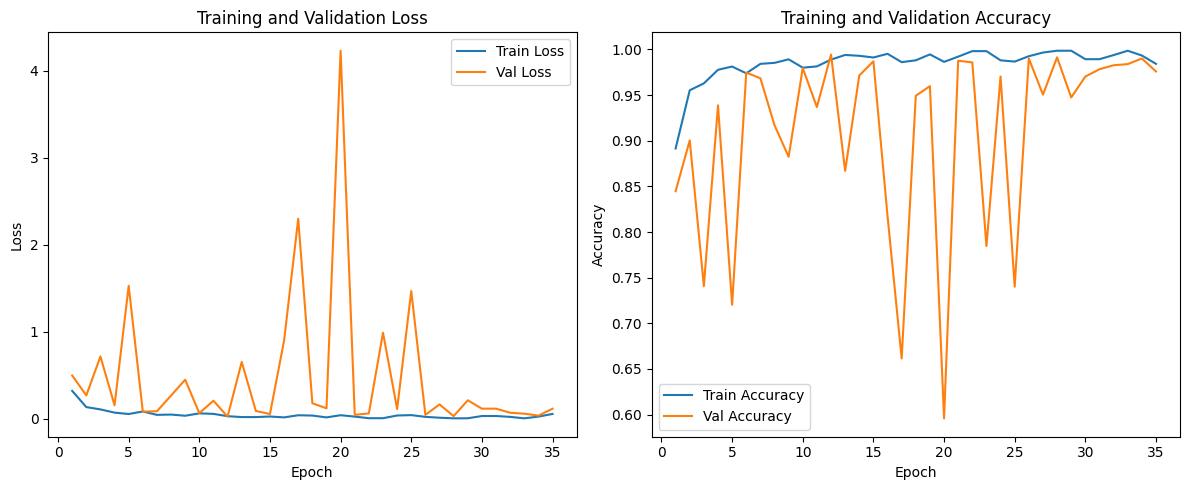

In [40]:
epochs = range(1, EPOCHS_NUM + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, history["train_loss"], label="Train Loss")
ax[0].plot(epochs, history["val_loss"], label="Val Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training and Validation Loss")
ax[0].legend()
ax[1].plot(epochs, history["train_acc"], label="Train Accuracy")
ax[1].plot(epochs, history["val_acc"], label="Val Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training and Validation Accuracy")
ax[1].legend()
plt.tight_layout()
plt.show()

## Augmentation

In [51]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Only for extra samples (random, label-preserving, on PIL)
aug_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=20),
    T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02)], p=0.4),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.15),
])

# Always applied (tensor + normalize)
base_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [52]:
from augumented_dataset import AugmentedPollenDataset

augmented_train_dataset = AugmentedToMaxPollenDataset(
    img_dir=train_dir,
    class_to_idx=class_to_idx,
    size_lookup=size_lookup,
    species_mean_lookup=species_mean_lookup,
    fill_missing_bool=True,        
    base_transform=base_transform,
    aug_transform=aug_transform,
    seed=42,
    shuffle_final=True,
    print_summary=True,
)


ModuleNotFoundError: No module named 'augumented_dataset'

In [ ]:

counts = Counter()
for base_idx, _ in augmented_train_dataset.mapping:
    _, class_name = augmented_train_dataset.samples[base_idx]
    counts[class_name] += 1

print(counts)  # each should be 870

In [ ]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(augmented_train_dataset))
val_size = len(augmented_train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(augmented_train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

In [ ]:

# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 35

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

history = {
    "train_loss": []
    ,"train_acc": []
    ,"val_loss": []
    ,"val_acc": []
}

best_val_acc = 0.0   # initialize before loop
print_every = 5

for epoch in range(1, EPOCHS_NUM + 1):
    train_loss, train_acc = train_epoch(model, train_loader, device, optimizer, loss_fn)
    val_recall_per_class, val_acc, val_loss = eval_epoch(model, val_loader, device, recall_metric, accuracy_metric, loss_fn)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train loss {train_loss:.4f}, train accuracy {train_acc:.4f} | ")

    print(f"val loss {val_loss:.4f}, val accuracy {val_acc:.4f}")
    if epoch == 1 or epoch % print_every == 0:
        print(f"Val Recall per class: {val_recall_per_class}")
    
    if val_acc > best_tval_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "aug_model.pth")
        print(f"Saved new best model with val accuracy {best_val_acc:.4f}! ") #And recall per class: {val_recall_per_class}.

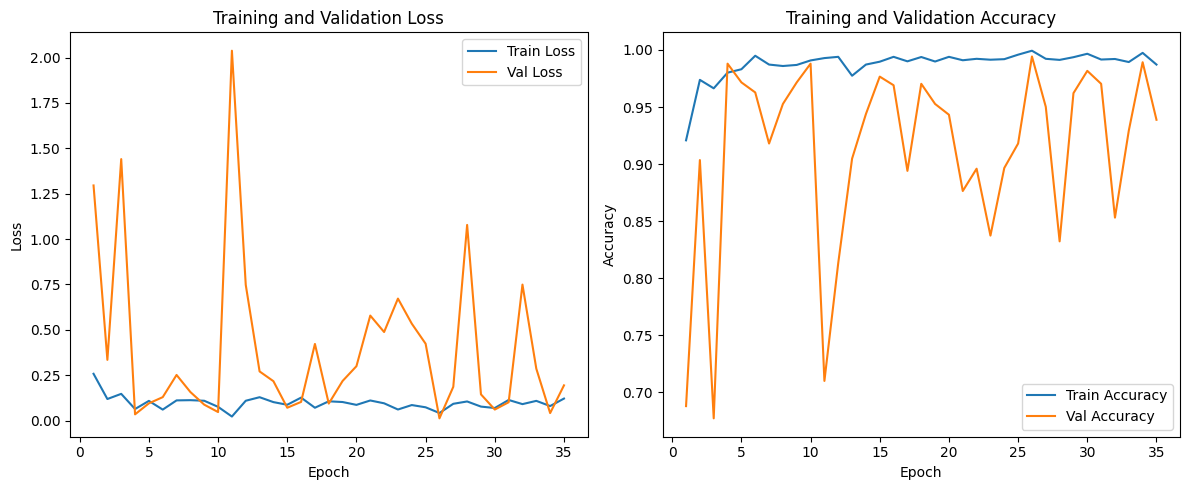

In [27]:
epochs = range(1, EPOCHS_NUM + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, history["train_loss"], label="Train Loss")
ax[0].plot(epochs, history["val_loss"], label="Val Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training and Validation Loss")
ax[0].legend()
ax[1].plot(epochs, history["train_acc"], label="Train Accuracy")
ax[1].plot(epochs, history["val_acc"], label="Val Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training and Validation Accuracy")
ax[1].legend()
plt.tight_layout()
plt.show()

In [10]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

Train subset size: 6337
Validation subset size: 1585
